In [4]:
import numpy as np
import matplotlib.pyplot as plt

def mc_volume(eps, d, N=2000000, seed=0):
    rng=np.random.default_rng(seed)
    X = rng.random((N, d))
    dB = np.minimum(X, 1-X).min(axis=1)
    dC = np.abs(X.sum(axis=1)-d/2)/np.sqrt(d)
    inside = (dB <= eps) & (dC <= eps)
    vol_est = inside.mean()
    se = np.sqrt(vol_est *(1-vol_est)/N)
    return vol_est, se

ds = [2, 3, 4, 5, 10, 20]
eps = 0.1
vols, ses = [], []
for d in ds:
    v, s = mc_volume(eps, d, N=2000000, seed=42)
    vols.append(v); ses.append(s)
    print(f'd={d} vol= {v:.5f} +- {s:.5f}')

d=2 vol= 0.05650 +- 0.00016
d=3 vol= 0.09352 +- 0.00021
d=4 vol= 0.12938 +- 0.00024
d=5 vol= 0.15673 +- 0.00026
d=10 vol= 0.23184 +- 0.00030
d=20 vol= 0.26488 +- 0.00031


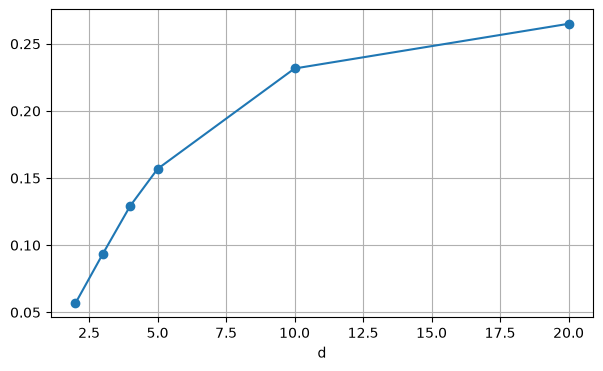

In [3]:
plt.figure(figsize=(7,4))
plt.errorbar(ds, vols, yerr=ses, fmt='o-', capsize=3)
plt.xlabel('d')
plt.grid(True)
plt.show()